<a href="https://colab.research.google.com/github/fellmaroua/BigData_tps/blob/Tp_BigData/TP03_BD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Data Loading

In [ ]:
import pandas as pd
df= pd.read_csv("/content/data.csv", encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


#3. Data Cleaning and Preprocessing


In [ ]:
# General statistics
print(df.describe())

# Missing values check
print("\nMissing values per column:")
print(df.isna().sum())


            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000   16791.000000
max     80995.000000   38970.000000   18287.000000

Missing values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [ ]:
# Check for missing values
print(df.isna().sum())
#drop missing values
df = df.dropna()
print(df.isna().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [ ]:
import numpy as np
from scipy.stats import zscore

# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert InvoiceDate to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

# Create new feature: Total Sales
df['TotalSales'] = df['Quantity'] * df['UnitPrice']

# Handle outliers in Quantity and TotalSales using Z-score
df = df[(np.abs(zscore(df['Quantity'])) < 3)]
df = df[(np.abs(zscore(df['TotalSales'])) < 3)]

print(" Cleaning done!")
print(df.info())

 Cleaning done!
<class 'pandas.core.frame.DataFrame'>
Index: 399804 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    399804 non-null  object        
 1   StockCode    399804 non-null  object        
 2   Description  399804 non-null  object        
 3   Quantity     399804 non-null  int64         
 4   InvoiceDate  399804 non-null  datetime64[ns]
 5   UnitPrice    399804 non-null  float64       
 6   CustomerID   399804 non-null  float64       
 7   Country      399804 non-null  object        
 8   TotalSales   399804 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.5+ MB
None


In [ ]:
# نظرة عامة على البيانات
print(df.info())

# إحصاءات وصفية
print(df.describe())

# توزيع الفئات في العمود الهدف
print(df['Country'].value_counts())


<class 'pandas.core.frame.DataFrame'>
Index: 399804 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    399804 non-null  object        
 1   StockCode    399804 non-null  object        
 2   Description  399804 non-null  object        
 3   Quantity     399804 non-null  int64         
 4   InvoiceDate  399804 non-null  datetime64[ns]
 5   UnitPrice    399804 non-null  float64       
 6   CustomerID   399804 non-null  float64       
 7   Country      399804 non-null  object        
 8   TotalSales   399804 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.5+ MB
None
            Quantity                    InvoiceDate      UnitPrice  \
count  399804.000000                         399804  399804.000000   
mean       10.873976  2011-07-10 11:49:26.607587840       3.005656   
min      -720.000000            2010-12-01 08:26

#4. Exploratory Data Analysis (EDA)

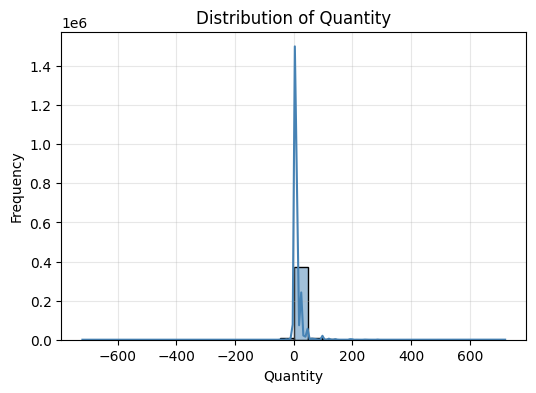

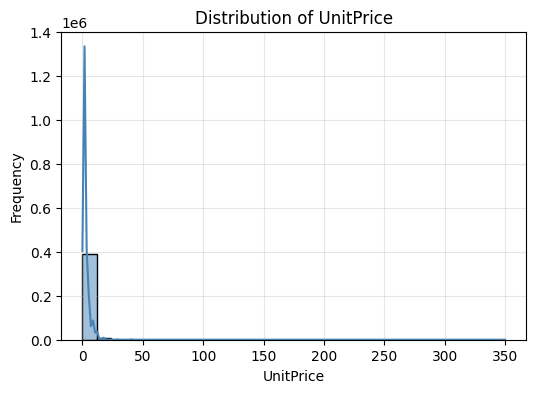

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# الأعمدة الرقمية التي نريد تحليلها
num_cols = ['Quantity', 'UnitPrice']

# رسم التوزيع لكل عمود عددي
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30, color='steelblue')
    plt.title(f"Distribution of {col}", fontsize=12)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.show()


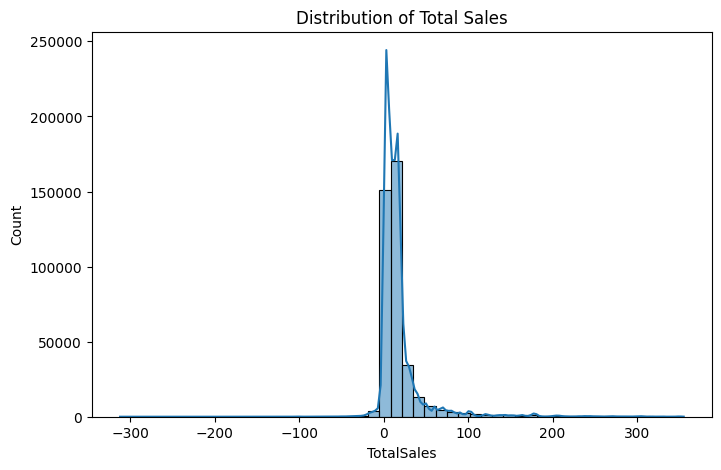

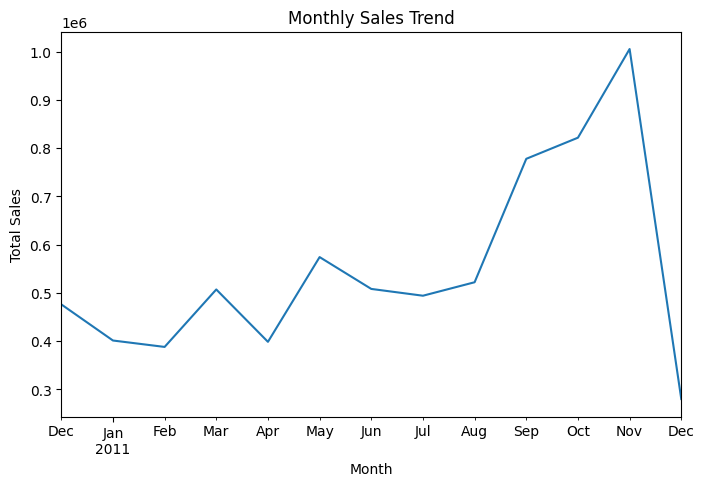

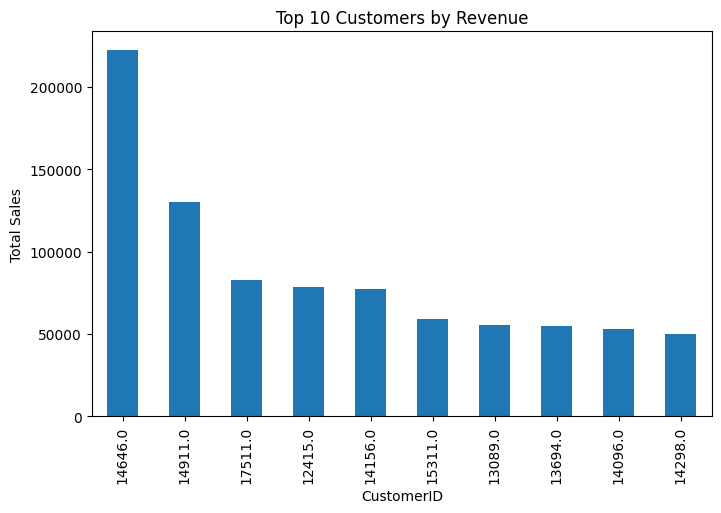

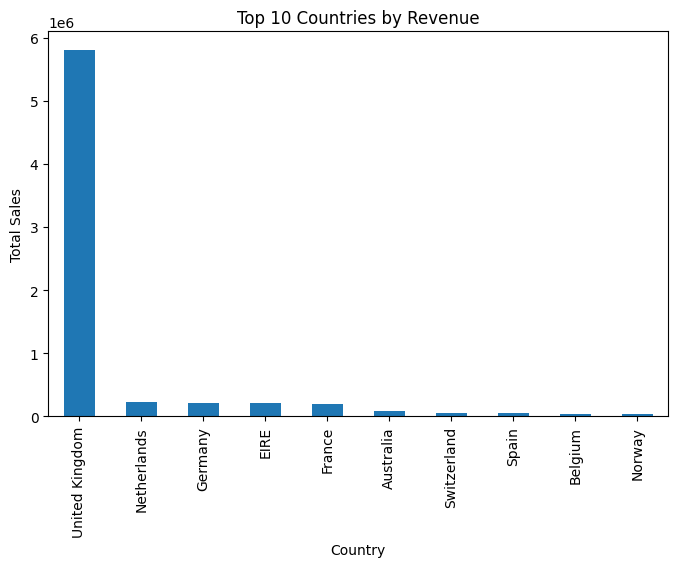

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
#  Distribution of Sales
plt.figure(figsize=(8,5))
sns.histplot(df['TotalSales'], bins=50, kde=True)
plt.title("Distribution of Total Sales")
plt.show()

#  Monthly sales trend
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('Month')['TotalSales'].sum()
monthly_sales.plot(kind='line', figsize=(8,5), title='Monthly Sales Trend')
plt.ylabel('Total Sales')
plt.show()

#  Top 10 Customers by Revenue
top_customers = df.groupby('CustomerID')['TotalSales'].sum().nlargest(10)
top_customers.plot(kind='bar', figsize=(8,5), title='Top 10 Customers by Revenue')
plt.ylabel('Total Sales')
plt.show()

#  Sales by Country
country_sales = df.groupby('Country')['TotalSales'].sum().sort_values(ascending=False).head(10)
country_sales.plot(kind='bar', figsize=(8,5), title='Top 10 Countries by Revenue')
plt.ylabel('Total Sales')
plt.show()


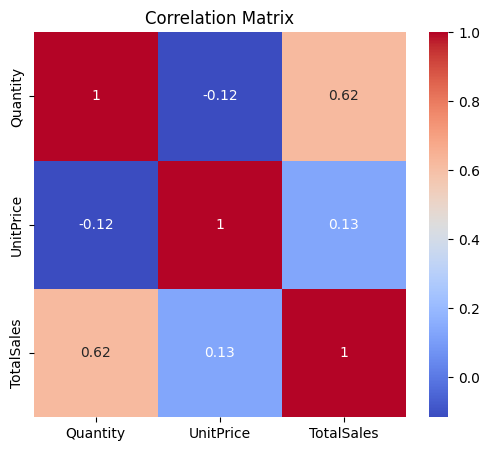

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(df[['Quantity', 'UnitPrice', 'TotalSales']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


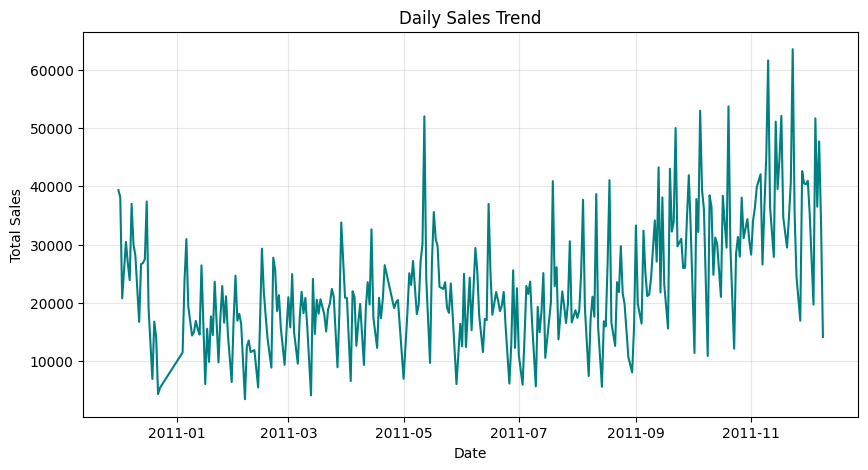

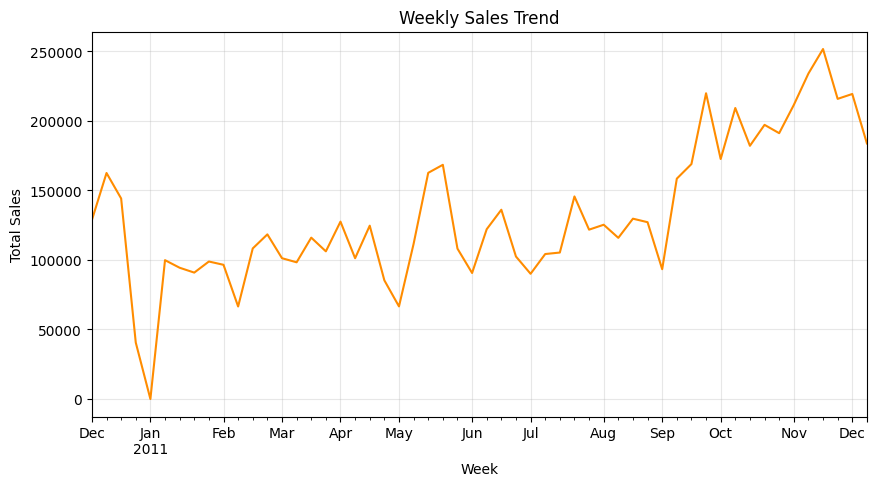

/tmp/ipython-input-1586190073.py:32: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.set_index('InvoiceDate').resample('M')['TotalSales'].sum()


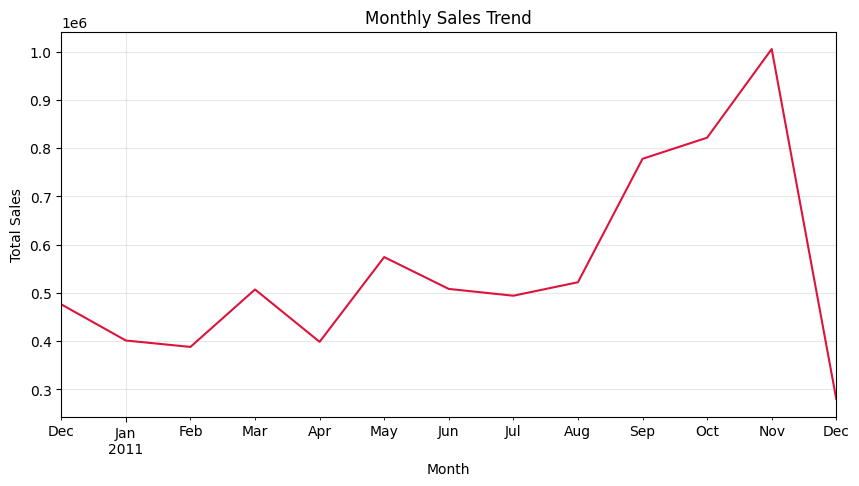

In [ ]:
import matplotlib.pyplot as plt

# تأكد من أن العمود الزمني في الصيغة الصحيحة
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

# إنشاء عمود جديد يمثل التاريخ فقط (بدون الوقت)
df['Date'] = df['InvoiceDate'].dt.date

#  إجمالي المبيعات اليومية
daily_sales = df.groupby('Date')['TotalSales'].sum()

plt.figure(figsize=(10,5))
daily_sales.plot(kind='line', color='teal')
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True, alpha=0.3)
plt.show()

#  إجمالي المبيعات الأسبوعية
weekly_sales = df.set_index('InvoiceDate').resample('W')['TotalSales'].sum()

plt.figure(figsize=(10,5))
weekly_sales.plot(kind='line', color='darkorange')
plt.title("Weekly Sales Trend")
plt.xlabel("Week")
plt.ylabel("Total Sales")
plt.grid(True, alpha=0.3)
plt.show()

#  إجمالي المبيعات الشهرية
monthly_sales = df.set_index('InvoiceDate').resample('M')['TotalSales'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind='line', color='crimson')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True, alpha=0.3)
plt.show()


/tmp/ipython-input-3962088963.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_sales.index, y=monthly_sales.values, palette="viridis")


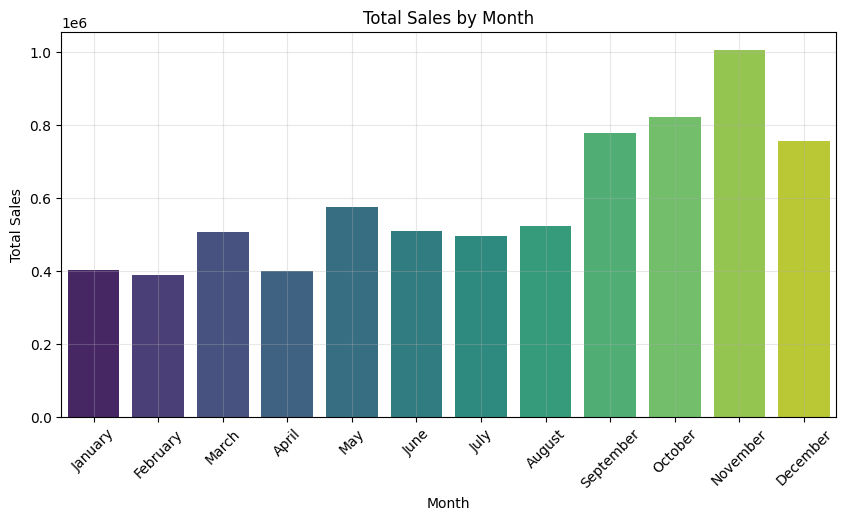

/tmp/ipython-input-3962088963.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_sales.index, y=day_sales.values, palette="crest")


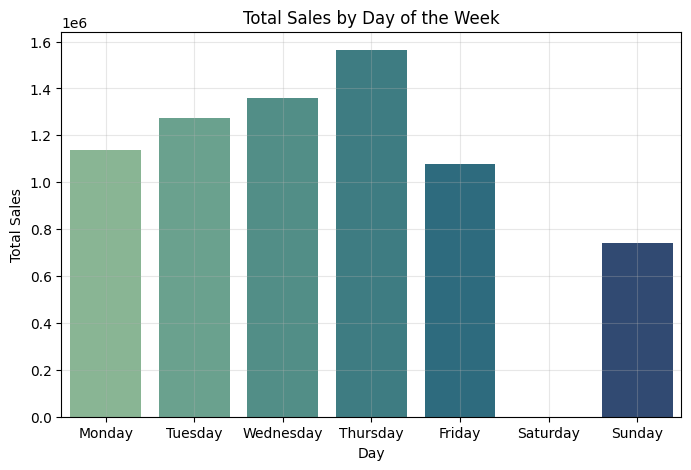

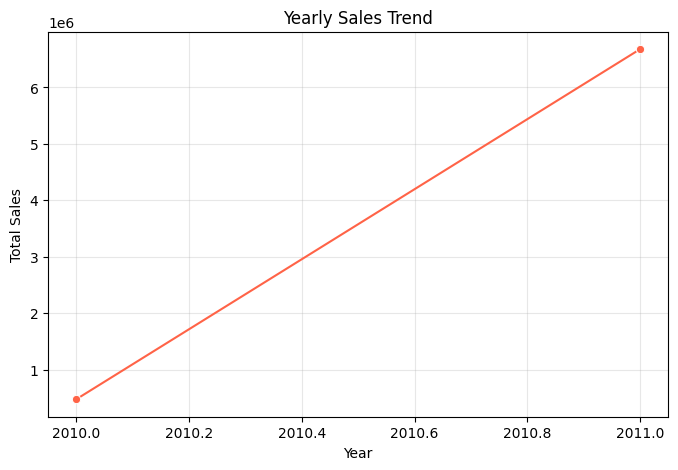

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# تأكد من تحويل التاريخ إلى datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

# استخراج الميزات الزمنية
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month_name()
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

#  مبيعات كل شهر (Seasonality)
monthly_sales = df.groupby('Month')['TotalSales'].sum().reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

plt.figure(figsize=(10,5))
sns.barplot(x=monthly_sales.index, y=monthly_sales.values, palette="viridis")
plt.title("Total Sales by Month")
plt.xticks(rotation=45)
plt.ylabel("Total Sales")
plt.xlabel("Month")
plt.grid(True, alpha=0.3)
plt.show()

#  مبيعات حسب أيام الأسبوع
day_sales = df.groupby('DayOfWeek')['TotalSales'].sum().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])

plt.figure(figsize=(8,5))
sns.barplot(x=day_sales.index, y=day_sales.values, palette="crest")
plt.title("Total Sales by Day of the Week")
plt.ylabel("Total Sales")
plt.xlabel("Day")
plt.grid(True, alpha=0.3)
plt.show()

#  الاتجاه العام لكل سنة (إذا كانت الداتا تغطي أكثر من سنة)
yearly_sales = df.groupby('Year')['TotalSales'].sum()

plt.figure(figsize=(8,5))
sns.lineplot(x=yearly_sales.index, y=yearly_sales.values, marker='o', color='tomato')
plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(True, alpha=0.3)
plt.show()


#5.Advanced Analysis (Optional)

R² Score: 0.409
RMSE: 23.64


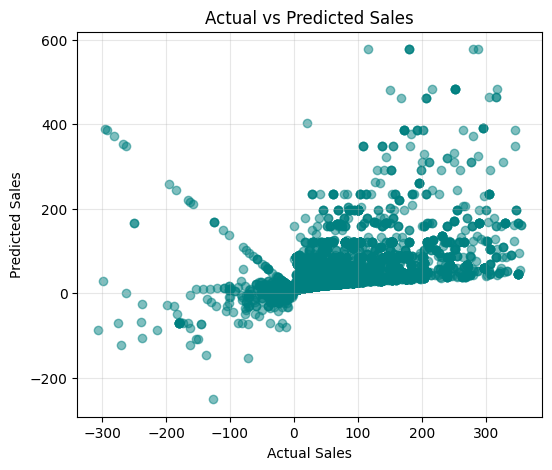

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

#  Features and Target
X = df[['Quantity', 'UnitPrice']]
y = df['TotalSales']

# Split data into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit linear regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("R² Score:", round(r2_score(y_test, y_pred), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))

# Visualize
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.title("Actual vs Predicted Sales")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.grid(True, alpha=0.3)
plt.show()


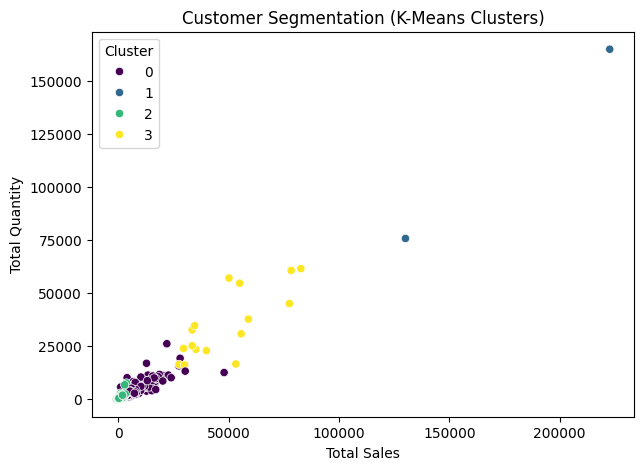

            TotalSales  NumPurchases       Quantity
Cluster                                            
0          7154.133183     20.519520    4087.546547
1        176375.940000    157.500000  120372.500000
2           909.978255      3.327988     547.121774
3         46243.084118     80.411765   33058.705882


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Create Customer Summary
customer_df = df.groupby('CustomerID').agg({
    'TotalSales': 'sum',
    'InvoiceNo': 'nunique',
    'Quantity': 'sum'
}).rename(columns={'InvoiceNo':'NumPurchases'})

# Normalize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_df)

# K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
customer_df['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualize clusters
plt.figure(figsize=(7,5))
sns.scatterplot(data=customer_df, x='TotalSales', y='Quantity', hue='Cluster', palette='viridis')
plt.title("Customer Segmentation (K-Means Clusters)")
plt.xlabel("Total Sales")
plt.ylabel("Total Quantity")
plt.legend(title='Cluster')
plt.show()

# Display cluster summary
print(customer_df.groupby('Cluster').mean())

##5. Data Visualization in Power BI

In [92]:
# حفظ البيانات بعد المعالجة في ملف CSV
output_path = "/content/data.csv"

df.to_csv(output_path, index=False, encoding='utf-8')

print(f" Le fichier a été sauvegardé avec succès : {output_path}")


 Le fichier a été sauvegardé avec succès : /content/data.csv
